# Day 039: AdaBoost — Adaptive Boosting
**Author:** Sahil-K-Y  
**Phase:** 4 - Boosting & Advanced Ensembles  
**Date:** Day 039

---



### Exercise 1: Custom AdaBoost with Decision Stumps from Scratch

### Step 1.1: Generate Synthetic Non-linear binary data

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_gaussian_quantiles
from sklearn.model_selection import train_test_split

# Non-linear datasets design
X1, y1 = make_gaussian_quantiles(cov=2., n_samples=300, n_features=2, n_classes=2, random_state=42)
X2, y2 = make_gaussian_quantiles(mean=(3, 3), cov=1.5, n_samples=200, n_features=2, n_classes=2, random_state=42)
X = np.concatenate((X1, X2))
y = np.concatenate((y1, -y2 + 1))
y = np.where(y == 0, -1, 1) # Converting targets to [-1, 1] for AdaBoost

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train Data Features shape: {X_train.shape} | Targets count: {np.bincount(y_train == 1)}")

Train Data Features shape: (400, 2) | Targets count: [197 203]


### Step 1.2: Build custom Decision Stump and AdaBoost Ensemble in NumPy


---

### 📖 Theoretical Concepts & Math

### 1. Decision Stumps & Weak Learners
AdaBoost (Adaptive Boosting) sequential ensemble models ko train karta hai. Iska base learner standard Decision Tree growth ke bajaye single-split binary decision boundaries (Decision Stumps) use karta hai.
- **Decision Stump**: Kisi ek feature split condition par data classification karta hai.
- **Weighted Adjustment**: Har model classification missteps par next learner ke weights adjust karta hai.


### 2. Weight Updates Formulation
Given training dataset size $N$ and targets $y_i \in \{-1, 1\}$:
1. Initialize weights: $w_i = \frac{1}{N}$.
2. For each estimator round $t = 1, \dots, T$:
   - Train weak classifier $h_t(x)$ minimizing weighted error rate:
     $$\epsilon_t = \frac{\sum_{i=1}^N w_i^{(t)} \mathbb{I}(y_i \ne h_t(x_i))}{\sum_{i=1}^N w_i^{(t)}}$$
   - Calculate structural coefficient alpha $\alpha_t$:
     $$\alpha_t = \frac{1}{2} \ln\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)$$
   - Update weights for next step:
     $$w_i^{(t+1)} = w_i^{(t)} \exp(-\alpha_t y_i h_t(x_i))$$
   - Renormalize weights: $w^{(t+1)} = w^{(t+1)} / \sum w^{(t+1)}$.

#### Step 1.2.1: Custom Decision Stump Class


In [2]:
class DecisionStump:
    def __init__(self):
        self.polarity = 1
        self.feature_idx = None
        self.threshold = None
        self.alpha = None

    def predict(self, X):
        n_samples = X.shape[0]
        X_column = X[:, self.feature_idx]
        predictions = np.ones(n_samples)
        if self.polarity == 1:
            predictions[X_column < self.threshold] = -1
        else:
            predictions[X_column > self.threshold] = -1
        return predictions



#### Step 1.2.2: Custom AdaBoost Ensemble Class


In [6]:
class CustomAdaBoost:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.clfs = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initializing weights: 1/N
        w = np.ones(n_samples) / n_samples
        for t in range(self.n_estimators):
            clf = DecisionStump()
            min_error = float('inf')

            # Search feature split parameters
            for feature_i in range(n_features):
                X_column = X[:, feature_i]
                thresholds = np.unique(X_column)
                for threshold in thresholds:
                    for polarity in [1, -1]:
                        predictions = np.ones(n_samples)
                        if polarity == 1:
                            predictions[X_column < threshold] = -1
                        else:
                            predictions[X_column > threshold] = -1
                        
                        # Compute weighted error rate
                        error = np.sum(w[y != predictions])
                        
                        if error < min_error:
                            min_error = error
                            clf.polarity = polarity
                            clf.feature_idx = feature_i
                            clf.threshold = threshold
            
            # Avoid division by zero with safety threshold
            EPS = 1e-10
            clf.alpha = 0.5 * np.log((1.0 - min_error + EPS) / (min_error + EPS))
            
            # Update weights
            predictions = clf.predict(X)
            w *= np.exp(-clf.alpha * y * predictions)
            w /= np.sum(w)  # Renormalizing
            
            self.clfs.append(clf)
            if (t+1) % 10 == 0 or t == 0:
                print(f"Estimator {t+1} trained. Alpha weight: {clf.alpha:.4f} | Error: {min_error:.4f}")

    def predict(self, X):
        clf_preds = [clf.alpha * clf.predict(X) for clf in self.clfs]
        return np.sign(np.sum(clf_preds, axis=0))



#### Step 1.2.3: Train Custom AdaBoost Model


In [7]:
# Run custom training
model = CustomAdaBoost(n_estimators=50)
model.fit(X_train, y_train)

Estimator 1 trained. Alpha weight: 0.2289 | Error: 0.3875
Estimator 10 trained. Alpha weight: 0.2009 | Error: 0.4009
Estimator 20 trained. Alpha weight: 0.1307 | Error: 0.4350
Estimator 30 trained. Alpha weight: 0.0889 | Error: 0.4557
Estimator 40 trained. Alpha weight: 0.0890 | Error: 0.4556
Estimator 50 trained. Alpha weight: 0.0733 | Error: 0.4634


### Step 1.3: Compare decision boundaries with Scikit-Learn

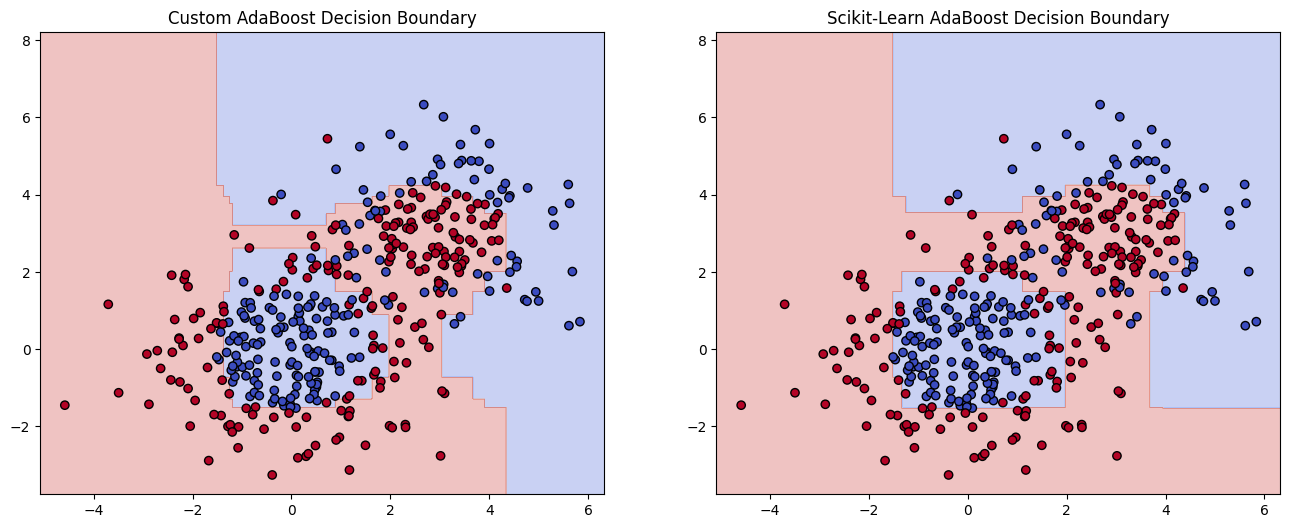

In [9]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# algorithm="SAMME" ko hata diya gaya hai kyunki yeh ab default hai
sk_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42,
)
sk_clf.fit(X_train, y_train)

# Plotting boundaries side-by-side
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Custom Model Boundary
Z_custom = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_custom = Z_custom.reshape(xx.shape)
axes[0].contourf(xx, yy, Z_custom, alpha=0.3, cmap="coolwarm")
axes[0].scatter(
    X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="k", cmap="coolwarm"
)
axes[0].set_title("Custom AdaBoost Decision Boundary")

# Sklearn Model Boundary
Z_sk = sk_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z_sk = Z_sk.reshape(xx.shape)
axes[1].contourf(xx, yy, Z_sk, alpha=0.3, cmap="coolwarm")
axes[1].scatter(
    X_train[:, 0], X_train[:, 1], c=y_train, edgecolors="k", cmap="coolwarm"
)
axes[1].set_title("Scikit-Learn AdaBoost Decision Boundary")

plt.show()

<Axes: >

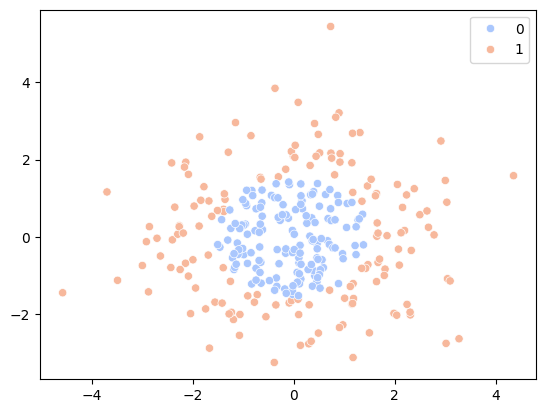

In [15]:
sns.scatterplot(x=X1[:, 0], y=X1[:, 1], hue=y1, palette="coolwarm")

In [13]:
import seaborn as sns